# Notebook 02: Preprocessing

## Objectif
Ce notebook a pour but de préparer les images brutes du dataset ACNE04 
pour qu'elles soient utilisables par nos modèles de Deep Learning.
Les images brutes sont de tailles très hétérogènes (de 331x270 à 3112x3456 pixels)
et contiennent beaucoup d'informations inutiles (fond, cheveux, vêtements).
On va nettoyer, recadrer et normaliser toutes les images.

## Les étapes qu'on va suivre

### Étape 1 : Détection et recadrage du visage
Pour chaque image, on utilise un détecteur DNN (Deep Neural Network) 
d'OpenCV pour détecter la zone du visage et recadrer l'image.

### Étape 2 :  Détection et recadrage du visage
Pour chaque image valide, on utilise MediaPipe pour :
- Détecter la zone du visage automatiquement
- Recadrer l'image sur cette zone uniquement
- Éliminer le fond, les cheveux, les vêtements

### Étape 3 :  Redimensionnement
Toutes les images recadrées sont redimensionnées à 224x224 pixels.
C'est la taille standard attendue par les modèles pré-entraînés 
comme EfficientNet et ResNet.

### Étape 4 :  Sauvegarde
Les images nettoyées et redimensionnées sont sauvegardées dans 
data/images_preprocessees/ avec leur label de sévérité.

### Étape 5 :  Split Train / Validation / Test
On divise le dataset propre en 3 parties :
- 70% pour l'entraînement (train)
- 15% pour la validation
- 15% pour le test
Le split est stratifié ,chaque partie contient la même proportion 
de chaque niveau de sévérité.

## Résultat attendu
À la fin de ce notebook, on aura :
- Un dataset propre sans images de mauvaise qualité
- Toutes les images en 224x224 pixels
- Un fichier CSV avec le nom de chaque image et son label
- 3 fichiers CSV séparés : train.csv, val.csv, test.csv

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

BASE_PATH = "../data/images_brutes/Classification"
IMAGES_PATH = os.path.join(BASE_PATH, "JPEGImages")
MODELE_PATH = "../data"

#Ici on va charger le modèle DNN depuis deux fichiers
#"deploy.prototxt => décrit l'architecture du réseau"
#".caffemodel  => contient les poids du réseau "
detecteur = cv2.dnn.readNetFromCaffe(
    os.path.join(MODELE_PATH, "deploy.prototxt"),
    os.path.join(MODELE_PATH, "res10_300x300_ssd_iter_140000.caffemodel")
)

print("Détecteur DNN chargé ✓")

Détecteur DNN chargé ✓


Meilleur score de confiance : 0.94


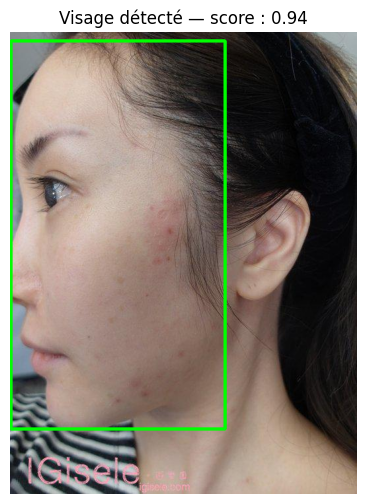

In [3]:
# Tester le détecteur DNN sur une image
image_test = os.path.join(IMAGES_PATH, "levle0_0.jpg")
img = cv2.imread(image_test)
h, w = img.shape[:2] #ici on récupère la hauteur et lalargeur de l'image

# Préparer l'image pour le DNN
blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
detecteur.setInput(blob) #ici on donne l'image au détecteur
detections = detecteur.forward() #on lance la détection et ça nous renvoie les coordonnées des tous les visages retrouvés

# Il faut savoir que DNN renvoie les coordonnées de toutes les zones de 
# l'image qui ressemblent à un visage avec un score => nous on veux garder 
# les coordonnes de la partie avec le score le plus fort.
# Trouver le visage avec le meilleur score

meilleur_score = 0
meilleure_box = None

for i in range(detections.shape[2]):
    score = detections[0, 0, i, 2]
    if score > meilleur_score:
        meilleur_score = score
        meilleure_box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])

print(f"Meilleur score de confiance : {meilleur_score:.2f}")

if meilleur_score > 0.5: # 0,5 est notre seuil de confiance, en dessous de ça on considère 
    # qu'aucun visage a été detecté
    x1, y1, x2, y2 = meilleure_box.astype(int)
    img_affich = img.copy()
    cv2.rectangle(img_affich, (x1, y1), (x2, y2), (0, 255, 0), 3)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_affich, cv2.COLOR_BGR2RGB))
    plt.title(f"Visage détecté — score : {meilleur_score:.2f}")
    plt.axis("off")
    plt.show()
else:
    print("Aucun visage détecté avec un score suffisant")

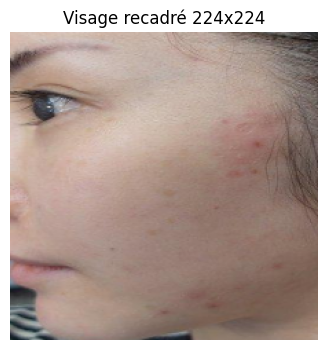

In [4]:
def recadrer_visage(chemin_image, seuil_confiance=0.5):
    img = cv2.imread(chemin_image) #charge l'image en tableau pixels
    h, w = img.shape[:2] #on récupère les dimensions de l'image
    
    # Détection DNN
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, 
                                  (300, 300), (104.0, 177.0, 123.0))
    detecteur.setInput(blob)
    detections = detecteur.forward()
    
    # Trouver le meilleur visage
    meilleur_score = 0
    meilleure_box = None
    for i in range(detections.shape[2]):
        score = detections[0, 0, i, 2]
        if score > meilleur_score:
            meilleur_score = score
            meilleure_box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
    
    if meilleur_score > seuil_confiance:
        x1, y1, x2, y2 = meilleure_box.astype(int)
        
        # Réduire le rectangle pour enlever les cheveux
        # On monte le bas du front de 20% et on resserre les côtés de 10%
        largeur = x2 - x1
        hauteur = y2 - y1
        x1 = x1 + int(largeur * 0.10)  # réduire gauche
        x2 = x2 - int(largeur * 0.10)  # réduire droite
        y1 = y1 + int(hauteur * 0.20)  # enlever cheveux en haut
        
        # S'assurer que les coordonnées sont dans l'image
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        visage = img[y1:y2, x1:x2]
        visage_redim = cv2.resize(visage, (224, 224))
        return visage_redim, meilleur_score
    
    return None, meilleur_score

# Tester sur notre image
visage, score = recadrer_visage(image_test)

if visage is not None:
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(visage, cv2.COLOR_BGR2RGB))
    plt.title(f"Visage recadré 224x224")
    plt.axis("off")
    plt.show()

In [5]:
# Créer le dossier de sortie
OUTPUT_PATH = "../data/images_preprocessees" # dossier où on sauvgarde nos images
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Lire TOUTES les annotations des 5 folds
annotations = []
for fold in range(5):
    fichier = os.path.join(BASE_PATH, f"NNEW_trainval_{fold}.txt")
    with open(fichier, "r") as f:
        lignes = f.readlines()
    for ligne in lignes:
        parties = ligne.strip().split()
        if len(parties) >= 2:
            annotations.append({
                "image": parties[0],
                "niveau": int(parties[1])
            })

# Supprimer les doublons
df = pd.DataFrame(annotations).drop_duplicates(subset=["image"])
print(f"Total images à traiter : {len(df)}")

# Traitement de toutes les images
images_ok = []
images_rejetees = []

for idx, row in df.iterrows():
    chemin = os.path.join(IMAGES_PATH, row["image"])
    visage, score = recadrer_visage(chemin)
    
    if visage is not None:
        nom_sortie = os.path.join(OUTPUT_PATH, row["image"])
        cv2.imwrite(nom_sortie, visage)
        images_ok.append({"image": row["image"], "niveau": row["niveau"]})
    else:
        images_rejetees.append(row["image"])
    
    # Afficher la progression tous les 100 images
    if (idx + 1) % 100 == 0:
        print(f"Traité : {idx + 1}/{len(df)} images")

print(f"\n✓ Images traitées avec succès : {len(images_ok)}")
print(f"✗ Images rejetées : {len(images_rejetees)}")

Total images à traiter : 1457
Traité : 100/1457 images
Traité : 200/1457 images
Traité : 300/1457 images
Traité : 400/1457 images
Traité : 500/1457 images
Traité : 600/1457 images
Traité : 700/1457 images
Traité : 800/1457 images
Traité : 900/1457 images
Traité : 1000/1457 images
Traité : 1100/1457 images
Traité : 1600/1457 images

✓ Images traitées avec succès : 1394
✗ Images rejetées : 63


In [6]:
# Sauvegarder les annotations dans un CSV
df_propre = pd.DataFrame(images_ok)
df_propre.to_csv("../data/dataset_propre.csv", index=False)

print(f"Dataset sauvegardé ✓")
print(f"Total images : {len(df_propre)}")
print("\nDistribution finale :")
print(df_propre["niveau"].value_counts().sort_index())


Dataset sauvegardé ✓
Total images : 1394

Distribution finale :
niveau
0    510
1    626
2    167
3     91
Name: count, dtype: int64


Nous avons adopté un split stratifié 70/15/15 conformément aux 
recommandations de la littérature pour les petits datasets en deep 
learning médical (Vrigazova, 2021 ; Tan et al., 2021). Le split stratifié garantit que chaque subset conserve la même 
proportion de chaque niveau de sévérité que le dataset complet — 
essentiel avec notre dataset déséquilibré (9% de niveau 3).

In [9]:
from sklearn.model_selection import train_test_split

df_propre = pd.read_csv("../data/dataset_propre.csv")

# Split stratifié 70/15/15
train, temp = train_test_split(
    df_propre, test_size=0.30, random_state=42, stratify=df_propre["niveau"]
)
val, test = train_test_split(
    temp, test_size=0.50, random_state=42, stratify=temp["niveau"]
)

# Sauvegarder
train.to_csv("../data/splits/train.csv", index=False)
val.to_csv("../data/splits/val.csv", index=False)
test.to_csv("../data/splits/test.csv", index=False)

print(f"Train : {len(train)} images")
print(f"Validation : {len(val)} images")
print(f"Test : {len(test)} images")

print("\nDistribution train :")
print(train["niveau"].value_counts().sort_index())

Train : 975 images
Validation : 209 images
Test : 210 images

Distribution train :
niveau
0    357
1    438
2    117
3     63
Name: count, dtype: int64
